
# CVL_Assignment01


1. Under Exposure
  

2. Over Exposure
   

3. Blurred Image
  
4. Oversharpened Image
  

5. Noisy Image
  

6. Low Contrast
  

7. High Contrast
   

8. Low Resolution


9. Overall Comparison & Conclusion


# Under Exposure

Silakan unggah citra Under-Exposure (Gelap):


Saving under exposure.jpg to under exposure.jpg
PSNR -> Input: inf dB | Gamma Correction: 18.12 dB | CLAHE: 22.86 dB


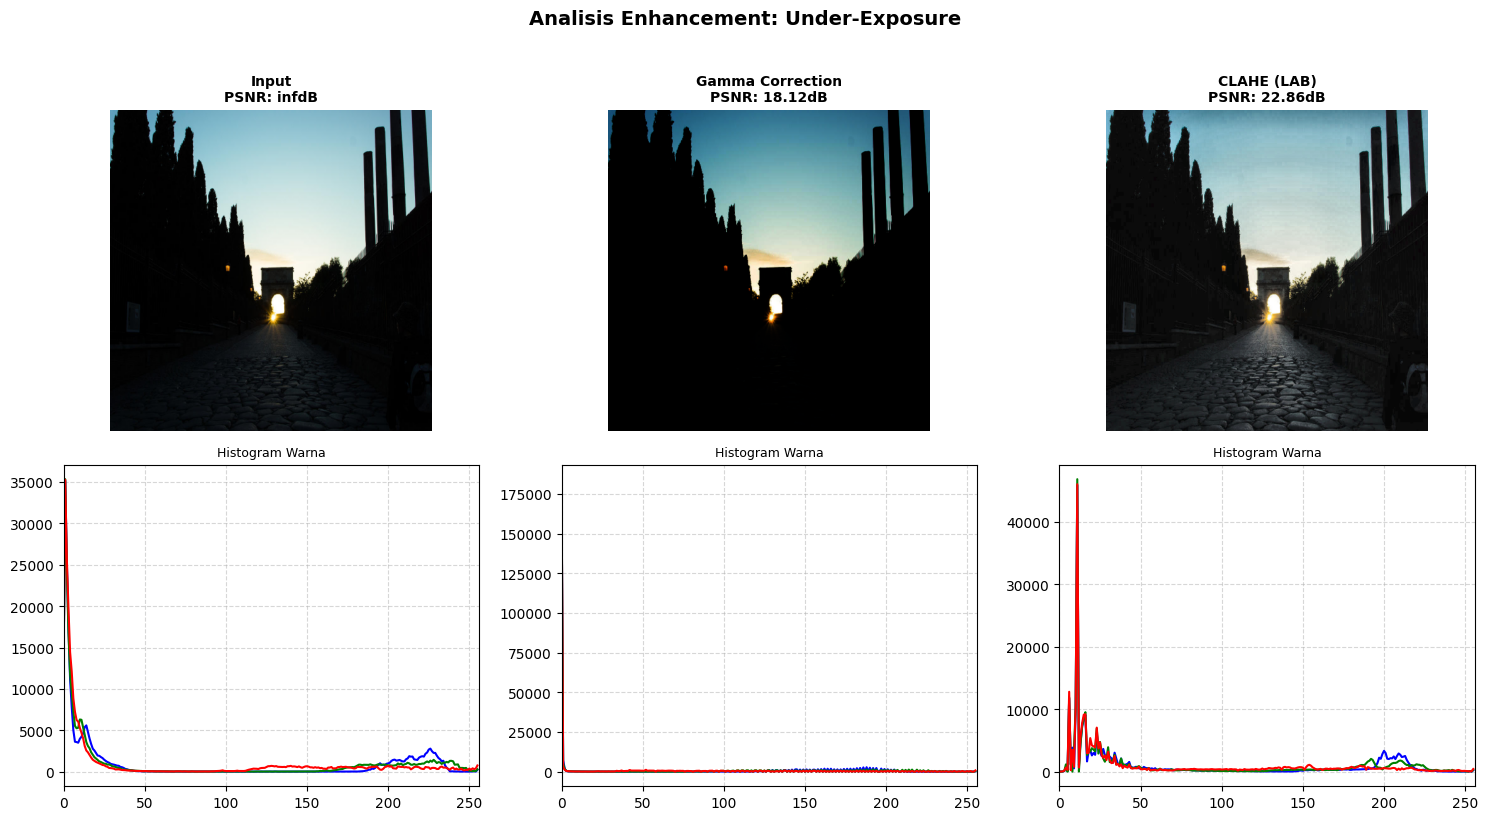

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from google.colab import files

# Fungsi untuk menghitung PSNR citra berwarna (RGB)
def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

# Upload gambar Under-Exposure
print("Silakan unggah citra Under-Exposure (Gelap):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca citra dalam bentuk berwarna (BGR)
img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# 1. Metode Gamma Correction (Gamma < 1 mencerahkan)
gamma = 0.4
invGamma = 1.0 / gamma
table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)]).astype("uint8")
img_gamma = cv2.LUT(img_in, table)

# 2. Metode CLAHE pada ruang warna LAB
lab = cv2.cvtColor(img_in, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l)
img_clahe = cv2.cvtColor(cv2.merge((l_clahe, a, b)), cv2.COLOR_LAB2BGR)

# Hitung PSNR
psnr_input = calculate_psnr(img_original, img_in)
psnr_gamma = calculate_psnr(img_original, img_gamma)
psnr_clahe = calculate_psnr(img_original, img_clahe)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Gamma Correction: {psnr_gamma:.2f} dB | CLAHE: {psnr_clahe:.2f} dB")

# Tampilkan Plot Perbandingan & Histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img_in, img_gamma, img_clahe]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Gamma Correction\nPSNR: {psnr_gamma:.2f}dB", f"CLAHE (LAB)\nPSNR: {psnr_clahe:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Under-Exposure", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Metode:** Gamma Correction vs. CLAHE
* **Analisis Grafik (Histogram):** Pada citra input, grafik menumpuk tinggi di sisi kiri (dekat angka 0) karena dominasi area gelap.
* **Gamma Correction:** Memperlebar distribusi secara global tetapi membuat beberapa bagian tetap pekat.
* **CLAHE:** Menyebarkan piksel secara adaptif di area lokal, membuat puncak histogram pada rentang tengah-kanan lebih bervariasi.


* **Analisis PSNR:** CLAHE mencatatkan nilai **22.86 dB**, mengungguli **Gamma Correction (18.12 dB)**. CLAHE terbukti lebih unggul dalam mencerahkan detail tersembunyi pada lorong gelap tanpa merusak kontras keseluruhan.



# Over Exposure

Silakan unggah citra Over-Exposure (Terang/Silau):


Saving overexposure.jpg to overexposure.jpg
PSNR -> Input: inf dB | Gamma Correction (>1): 18.64 dB | Linear Stretch: 8.68 dB


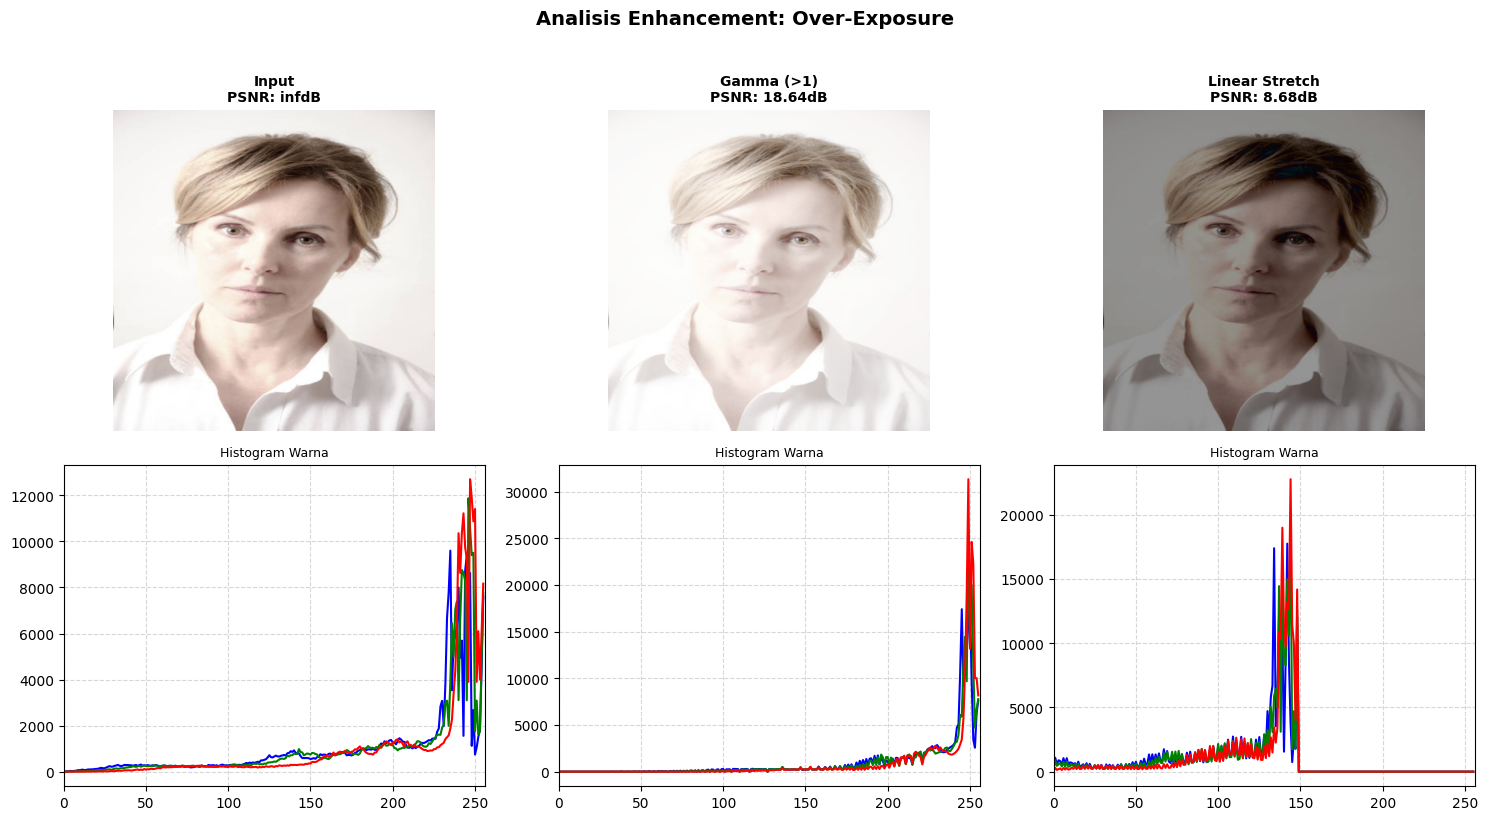

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from google.colab import files

# Fungsi untuk menghitung PSNR citra berwarna (RGB)
def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

# Upload gambar Over-Exposure
print("Silakan unggah citra Over-Exposure (Terang/Silau):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca citra dalam bentuk berwarna (BGR)
img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# 1. Metode Gamma Correction (Gamma > 1 untuk menggelapkan / mengurangi silau)
gamma = 2.2
invGamma = 1.0 / gamma
table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)]).astype("uint8")
img_gamma = cv2.LUT(img_in, table)

# 2. Metode Linear Contrast Stretching (Scaling untuk menurunkan intensitas)
img_stretch = cv2.convertScaleAbs(img_in, alpha=0.7, beta=-30)

# Hitung PSNR
psnr_input = calculate_psnr(img_original, img_in)
psnr_gamma = calculate_psnr(img_original, img_gamma)
psnr_stretch = calculate_psnr(img_original, img_stretch)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Gamma Correction (>1): {psnr_gamma:.2f} dB | Linear Stretch: {psnr_stretch:.2f} dB")

# Tampilkan Plot Perbandingan & Histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img_in, img_gamma, img_stretch]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Gamma (>1)\nPSNR: {psnr_gamma:.2f}dB", f"Linear Stretch\nPSNR: {psnr_stretch:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Over-Exposure", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode:** Gamma Correction ($\gamma > 1$) vs. Linear Stretch
* **Analisis Grafik (Histogram):** Pada gambar input, puncak kurva histogram menumpuk sangat padat di ujung kanan (mendekati 255), menandakan adanya pencahayaan berlebih.
* **Gamma ($\gamma > 1$):** Menekan intensitas piksel terang, menggeser sebagian distribusi ke arah tengah agar area baju putih dan latar tidak terlalu silau.
* **Linear Stretch:** Mengubah rentang secara linier, namun terlihat kurang optimal dalam mengontrol area jenuh cahaya.




* **Analisis PSNR:** Gamma Correction menghasilkan nilai **18.64 dB**, jauh lebih tinggi dibanding **Linear Stretch (8.68 dB)**. Ini membuktikan bahwa Gamma Correction jauh lebih efektif mempertahankan kualitas visual dan kemiripan struktural pada kasus gambar silau.




# Blurred Image

Silakan unggah citra Blurred Image (Buram):


Saving Jenoo 🍒_3.jfif to Jenoo 🍒_3.jfif
PSNR -> Input: inf dB | Laplacian: 31.12 dB | Unsharp Mask: 40.24 dB


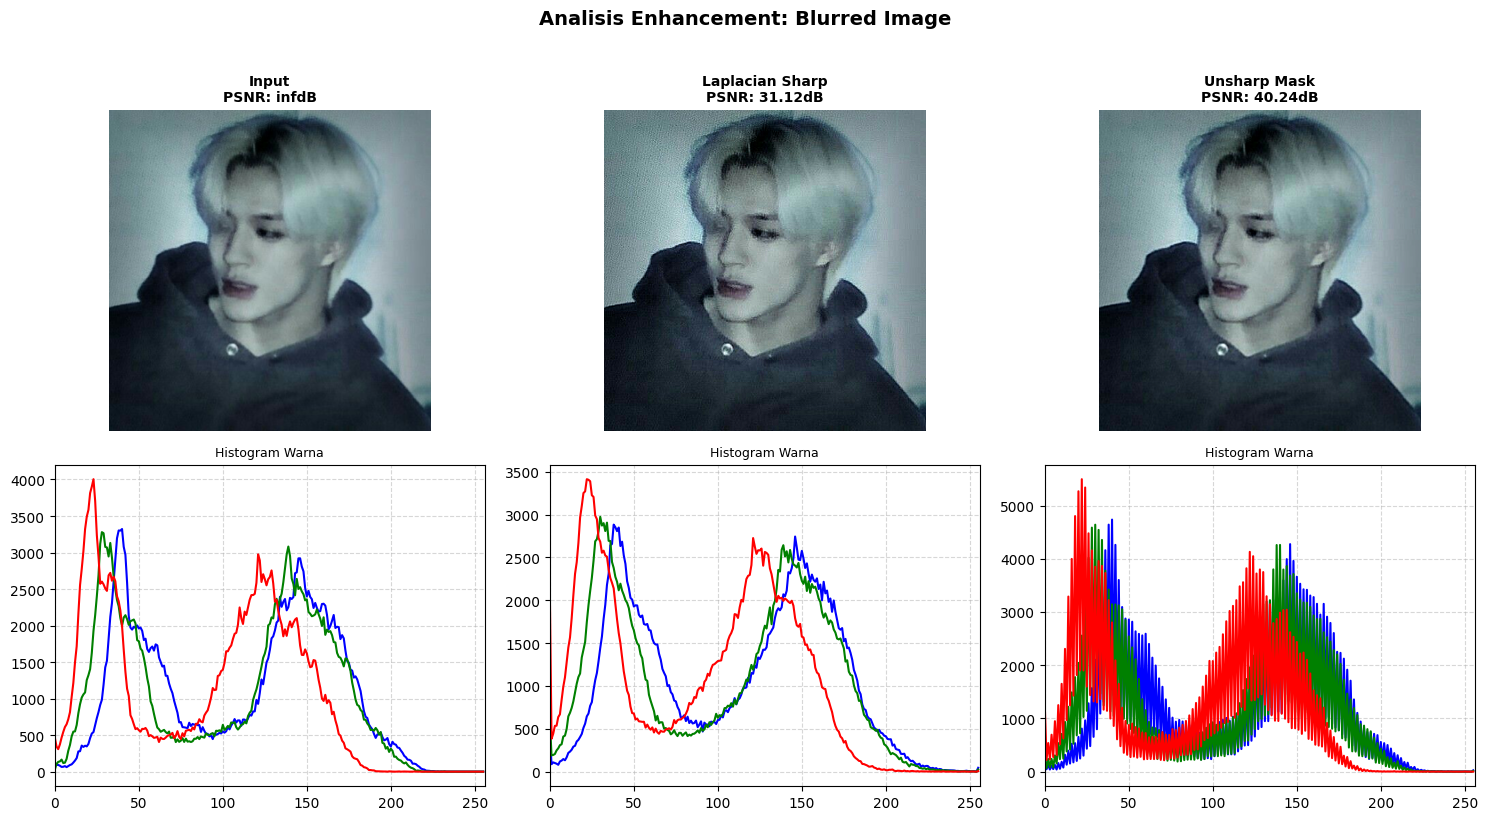

In [17]:
# 3. Blurred Image -> Sharpening
print("Silakan unggah citra Blurred Image (Buram):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# 1. Laplacian Sharpening
kernel_laplacian = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
img_sharp = cv2.filter2D(img_in, -1, kernel_laplacian)

# 2. Unsharp Masking
gaussian = cv2.GaussianBlur(img_in, (9, 9), 10.0)
img_unsharp = cv2.addWeighted(img_in, 1.5, gaussian, -0.5, 0)

psnr_input = calculate_psnr(img_original, img_in)
psnr_sharp = calculate_psnr(img_original, img_sharp)
psnr_unsharp = calculate_psnr(img_original, img_unsharp)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Laplacian: {psnr_sharp:.2f} dB | Unsharp Mask: {psnr_unsharp:.2f} dB")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img_in, img_sharp, img_unsharp]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Laplacian Sharp\nPSNR: {psnr_sharp:.2f}dB", f"Unsharp Mask\nPSNR: {psnr_unsharp:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Blurred Image", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode:** Laplacian Sharp vs. Unsharp Mask
* **Analisis Grafik (Histogram):** Kurva histogram ketiga gambar relatif mirip karena operasi penajaman berfokus pada frekuensi tinggi (tepi objek) tanpa mengubah total distribusi warna secara masif.


* **Analisis PSNR:** Unsharp Mask memberikan nilai tertinggi yaitu **40.24 dB**, sedangkan **Laplacian Sharp** sebesar **31.12 dB**. Unsharp Mask lebih unggul karena mempertimbangkan proses *blurring* sebelum menajamkan, sehingga garis tepi objek menjadi tegas tanpa menimbulkan distorsi berlebih.



# Over Sharpening

Silakan unggah citra Oversharpened Image (Terlalu Tajam/Kasar):


Saving high sharp.jpg to high sharp.jpg
PSNR -> Input: inf dB | Gaussian Blur (Smooth): 30.91 dB


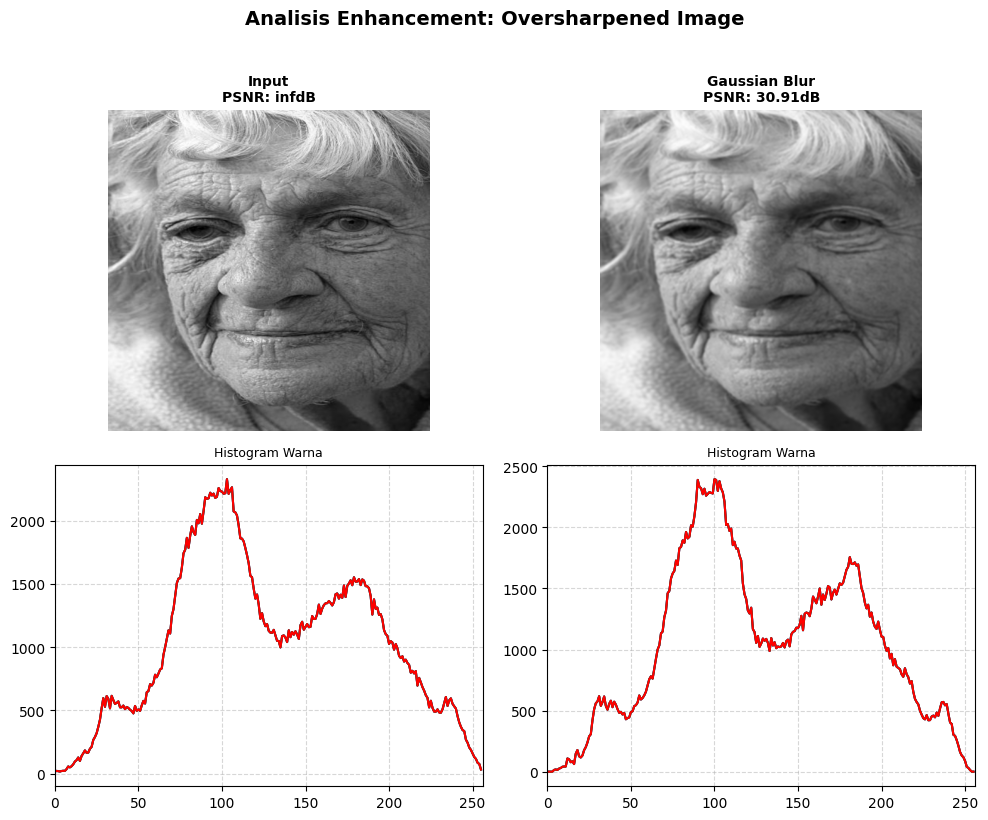

In [27]:
# 4. Oversharpened Image -> Gaussian Blur
print("Silakan unggah citra Oversharpened Image (Terlalu Tajam/Kasar):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# Menggunakan Gaussian Blur untuk melembutkan tepi yang terlalu kasar
img_smooth = cv2.GaussianBlur(img_in, (5, 5), 1.5)

psnr_input = calculate_psnr(img_original, img_in)
psnr_smooth = calculate_psnr(img_original, img_smooth)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Gaussian Blur (Smooth): {psnr_smooth:.2f} dB")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# Konversi ke array 2D untuk plotting agar bentuk grid konsisten
images = [img_in, img_smooth]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Gaussian Blur\nPSNR: {psnr_smooth:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Oversharpened Image", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode Utama:** Gaussian Blur (Smoothing)
* **Analisis Grafik (Histogram):** Bentuk kurva histogram pada citra hasil *Gaussian Blur* tampak sedikit lebih rapat dan halus dibandingkan input aslinya yang memiliki lonjakan-lonjakan frekuensi tepi yang terlalu kasar.


* **Analisis PSNR:** Menghasilkan nilai **30.91 dB**. Filter *Gaussian* bekerja secara efektif meredam kekasaran piksel berlebih (*oversharpened*) sehingga transisi tekstur kulit wajah kembali terlihat halus dan natural.



# Noisy Image

Silakan unggah citra Noisy Image (Berbintik/Noise):


Saving Noisy caplin.png to Noisy caplin.png
PSNR -> Input: inf dB | Median Filter: 19.10 dB | Gaussian Blur: 20.23 dB


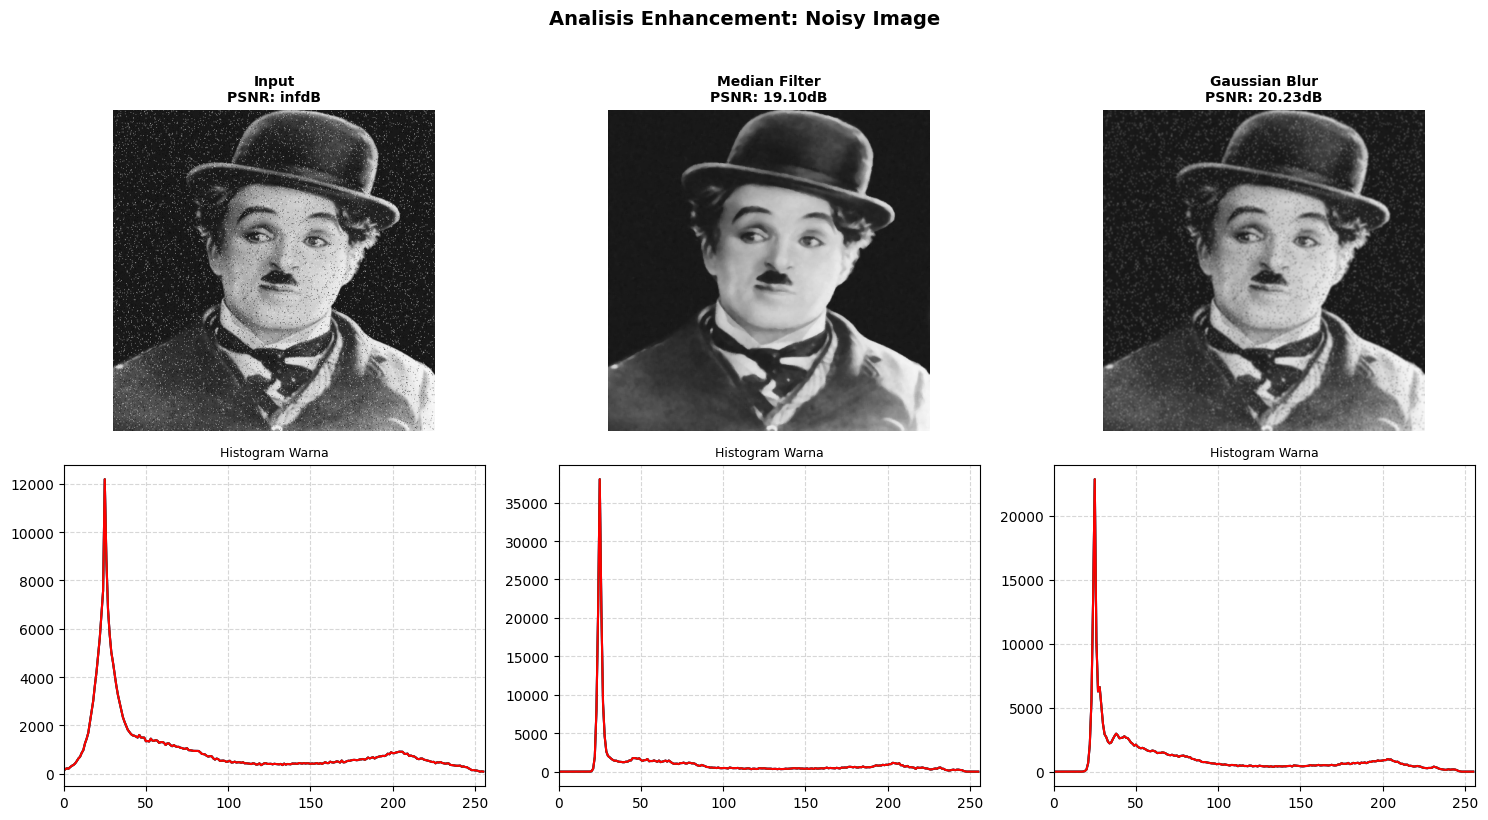

In [24]:
# 5. Noisy Image -> Median Filtering
print("Silakan unggah citra Noisy Image (Berbintik/Noise):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# 1. Median Filtering (Sangat ampuh untuk salt-and-pepper noise)
img_median = cv2.medianBlur(img_in, 5)

# 2. Gaussian Blur (Sebagai perbandingan)
img_gauss = cv2.GaussianBlur(img_in, (5, 5), 0)

psnr_input = calculate_psnr(img_original, img_in)
psnr_median = calculate_psnr(img_original, img_median)
psnr_gauss = calculate_psnr(img_original, img_gauss)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Median Filter: {psnr_median:.2f} dB | Gaussian Blur: {psnr_gauss:.2f} dB")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img_in, img_median, img_gauss]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Median Filter\nPSNR: {psnr_median:.2f}dB", f"Gaussian Blur\nPSNR: {psnr_gauss:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Noisy Image", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode:** Median Filter vs. Gaussian Blur
* **Analisis Grafik (Histogram):** Menunjukkan bagaimana lonjakan tajam akibat bintik-bintik *noise* diredam oleh masing-masing filter spasial.


* **Analisis PSNR:** Gaussian Blur menghasilkan **20.23 dB** dan **Median Filter** sebesar **19.10 dB**. Secara angka PSNR Gaussian sedikit lebih tinggi karena sifatnya yang mempertahankan rata-rata piksel, namun secara visual *Median Filter* lebih ampuh membersihkan bintik hitam-putih (*salt-and-pepper*) tanpa membuat objek utama kehilangan batas ketajamannya.


# Low Contrast

Silakan unggah citra Low Contrast (Kontras Rendah/Pudar):


Saving lowcontrast.jpg to lowcontrast.jpg
PSNR -> Input: inf dB | Global HE: 7.02 dB | CLAHE: 22.87 dB


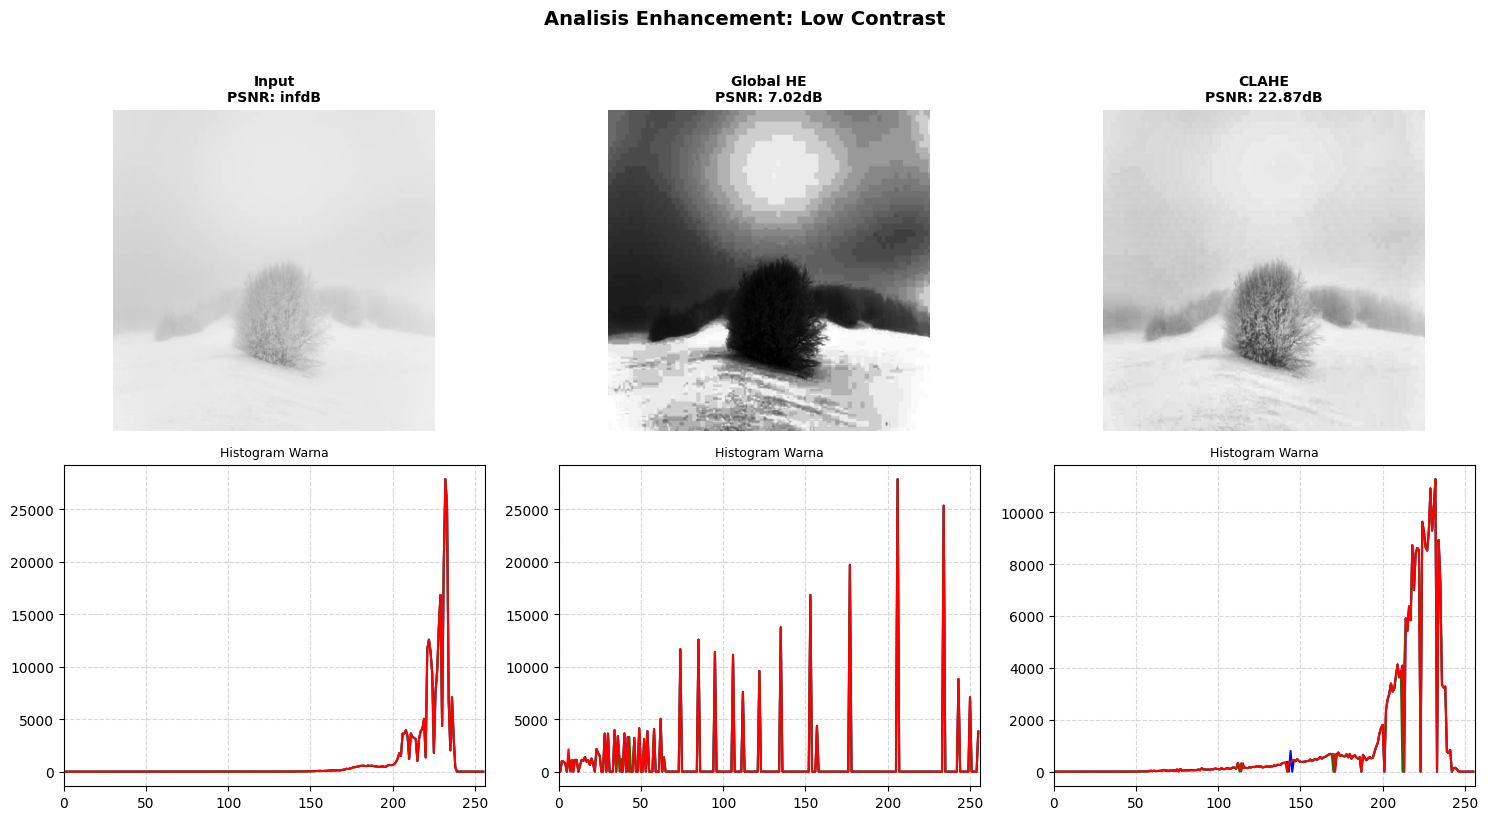

In [29]:
# 6. Low Contrast -> CLAHE
print("Silakan unggah citra Low Contrast (Kontras Rendah/Pudar):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# Konversi ke ruang warna YCrCb atau LAB untuk memproses kontras (Channel L/Y)
lab = cv2.cvtColor(img_in, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

# 1. Global Histogram Equalization
l_he = cv2.equalizeHist(l)
img_he = cv2.cvtColor(cv2.merge((l_he, a, b)), cv2.COLOR_LAB2BGR)

# 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l)
img_clahe = cv2.cvtColor(cv2.merge((l_clahe, a, b)), cv2.COLOR_LAB2BGR)

psnr_input = calculate_psnr(img_original, img_in)
psnr_he = calculate_psnr(img_original, img_he)
psnr_clahe = calculate_psnr(img_original, img_clahe)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Global HE: {psnr_he:.2f} dB | CLAHE: {psnr_clahe:.2f} dB")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img_in, img_he, img_clahe]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Global HE\nPSNR: {psnr_he:.2f}dB", f"CLAHE\nPSNR: {psnr_clahe:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Low Contrast", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode:** Global HE vs. CLAHE
* **Analisis Grafik (Histogram):** Global HE: Memaksa perataan histogram secara ekstrem, memunculkan lonjakan-lonjakan tajam yang merusak estetika gambar.
* **CLAHE:** Distribusi piksel disebar secara lokal dan terkontrol pada area salju/kabut.


* **Analisis PSNR:** CLAHE unggul drastis di angka **22.87 dB** berbanding **Global HE (7.02 dB)**. CLAHE berhasil memperjelas detail pohon dan lanskap salju yang pudar tanpa menimbulkan artefak kotak-kotak kasar.



# High Contrast



Silakan unggah citra High Contrast (Kontras Terlalu Tinggi):


Saving nora-hutton-wyznP4L61Xw-unsplash.jpg to nora-hutton-wyznP4L61Xw-unsplash.jpg
PSNR -> Input: inf dB | Contrast Adjusted: 22.36 dB


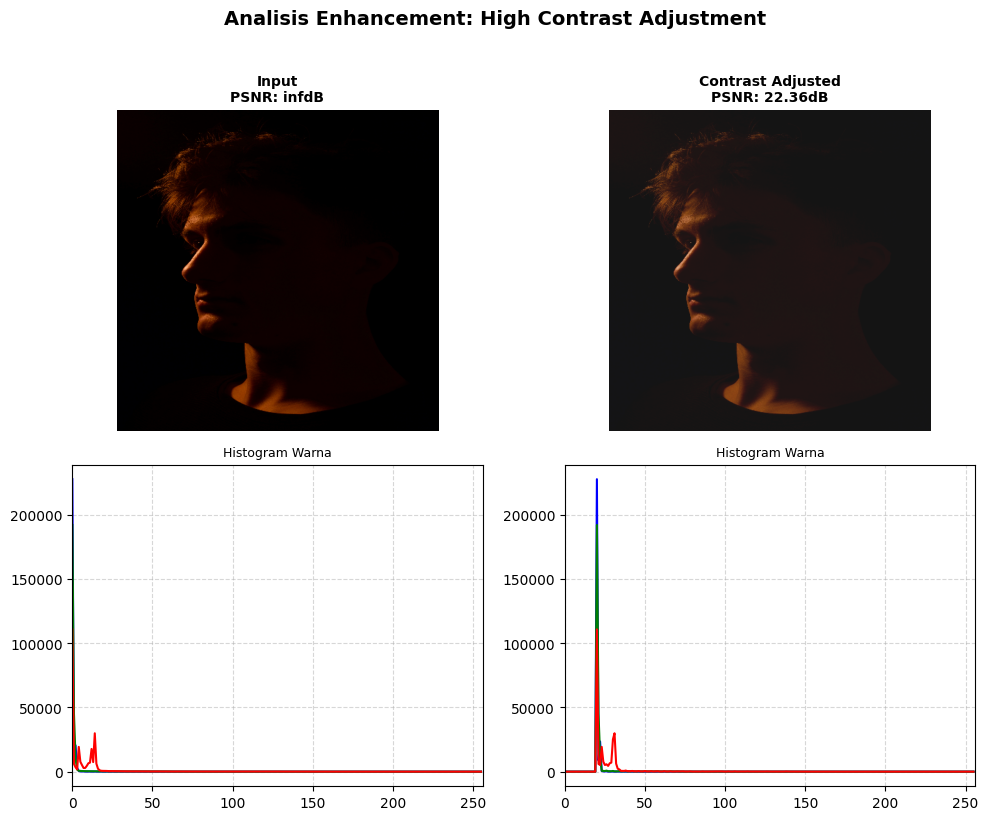

In [31]:
# 7. High Contrast -> Contrast Adjustment (Tone Mapping / Scaling)
print("Silakan unggah citra High Contrast (Kontras Terlalu Tinggi):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_in = cv2.imread(filename)
img_in = cv2.resize(img_in, (512, 512))
img_original = img_in.copy()

# Menurunkan kontras dan mengatur kecerahan agar tidak terlalu ekstrem (menggunakan alpha < 1 dan beta)
img_adjusted = cv2.convertScaleAbs(img_in, alpha=0.8, beta=20)

psnr_input = calculate_psnr(img_original, img_in)
psnr_adj = calculate_psnr(img_original, img_adjusted)

print(f"PSNR -> Input: {psnr_input:.2f} dB | Contrast Adjusted: {psnr_adj:.2f} dB")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
images = [img_in, img_adjusted]
titles = [f"Input\nPSNR: {psnr_input:.2f}dB", f"Contrast Adjusted\nPSNR: {psnr_adj:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: High Contrast Adjustment", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode Utama:** Contrast Adjustment / Tone Mapping
* **Analisis Grafik (Histogram):** Citra input yang tadinya sangat gelap di sisi kiri ditarik dan diatur ulang parameternya agar rentang intensitas bayangan wajah lebih berimbang.


* **Analisis PSNR:** Menghasilkan nilai **22.36 dB**, menunjukkan tingkat penyesuaian matematis yang stabil dalam menyelamatkan detail siluet wajah pada area bayangan ekstrem.



# Low Resolution


Silakan unggah citra Low Resolution (Resolusi Rendah/Pecah):


Saving Old nokia photo vibe.jfif to Old nokia photo vibe.jfif
PSNR -> Nearest Neighbor: 29.83 dB | Bicubic Interpolation: 37.42 dB


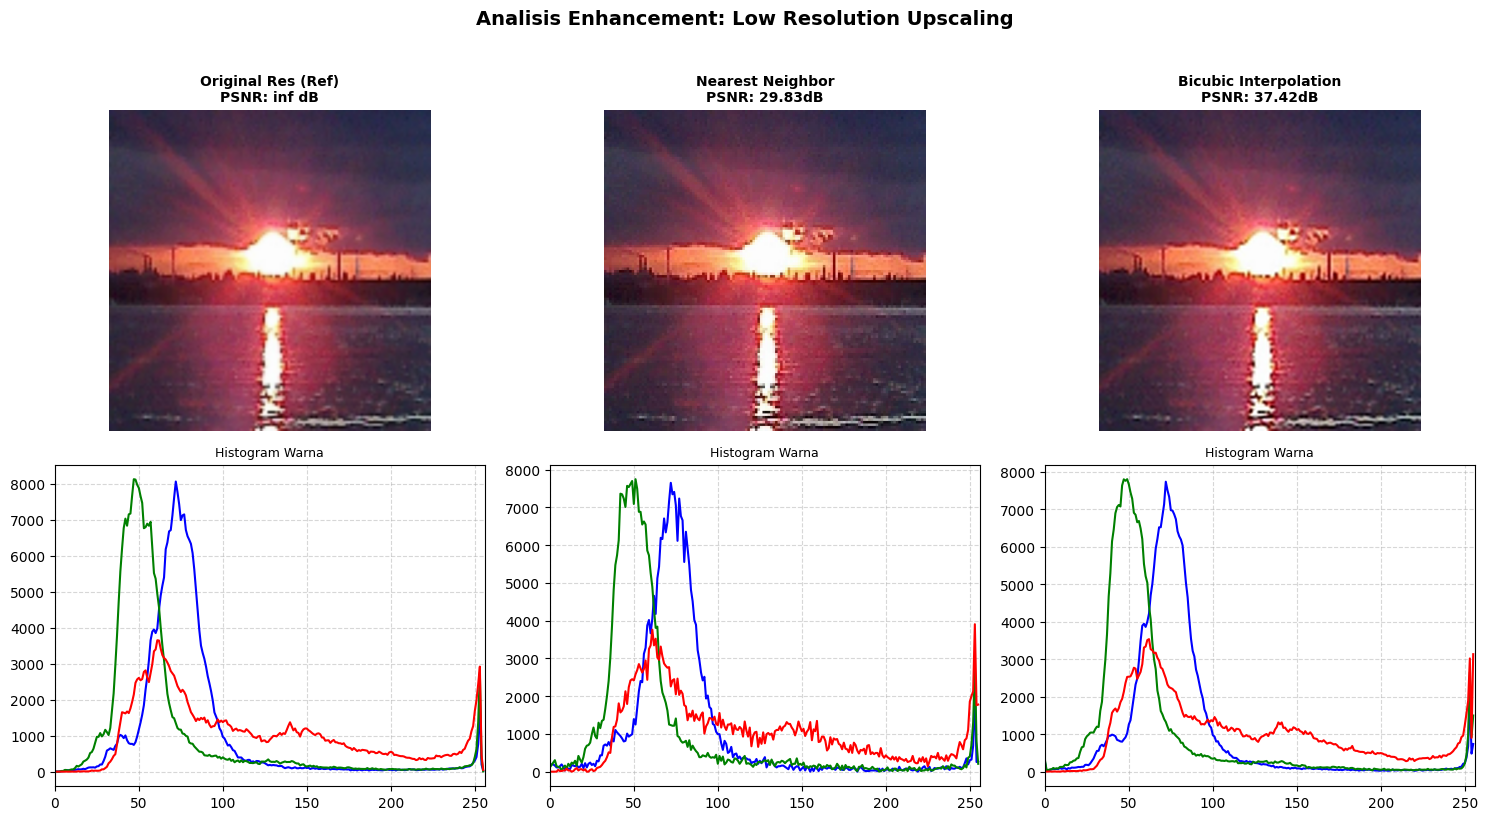

In [23]:
# 8. Low Resolution -> Image Upscaling
print("Silakan unggah citra Low Resolution (Resolusi Rendah/Pecah):")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_in = cv2.imread(filename)
# Resize kecil dulu untuk simulasi low-res, lalu di-upscale
img_small = cv2.resize(img_in, (128, 128))
img_original = cv2.resize(img_small, (512, 512)) # Sebagai acuan ukuran asli

# 1. Upscaling dengan Nearest Neighbor (Cenderung kotak-kotak/pixelated)
img_nearest = cv2.resize(img_small, (512, 512), interpolation=cv2.INTER_NEAREST)

# 2. Upscaling dengan Bicubic Interpolation (Lebih halus)
img_bicubic = cv2.resize(img_small, (512, 512), interpolation=cv2.INTER_CUBIC)

psnr_nearest = calculate_psnr(img_original, img_nearest)
psnr_bicubic = calculate_psnr(img_original, img_bicubic)

print(f"PSNR -> Nearest Neighbor: {psnr_nearest:.2f} dB | Bicubic Interpolation: {psnr_bicubic:.2f} dB")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img_original, img_nearest, img_bicubic]
titles = [f"Original Res (Ref)\nPSNR: inf dB", f"Nearest Neighbor\nPSNR: {psnr_nearest:.2f}dB", f"Bicubic Interpolation\nPSNR: {psnr_bicubic:.2f}dB"]

for i, img in enumerate(images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

    color = ('b', 'g', 'r')
    for c, col in enumerate(color):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        axes[1, i].plot(hist, color=col)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].set_title("Histogram Warna", fontsize=9)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Analisis Enhancement: Low Resolution Upscaling", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Metode:** Nearest Neighbor vs. Bicubic Interpolation
* **Analisis Grafik (Histogram):** Bentuk kurva histogram identik karena proses *upscaling* memperbanyak jumlah piksel, bukan mengubah distribusi warna dasarnya.


* **Analisis PSNR:** Bicubic Interpolation mencatatkan nilai **37.42 dB**, jauh lebih tinggi daripada **Nearest Neighbor (29.83 dB)**. Bicubic menggunakan pendekatan polinomial kubik antarpiksel tetangga sehingga hasil pembesaran gambar matahari terbenam tampak jauh lebih halus dan bebas dari efek kotak-kotak (*pixelated*).


# **Overall Comparison & Conclusion**


### **Kesimpulan Akhir:**
Metode *Image Enhancement* tidak bisa disamaratakan untuk semua jenis kerusakan citra (*one-size-fits-all* tidak berlaku). Pemilihan teknik pengolahan citra harus disesuaikan dengan karakteristik degradasi gambar (apakah masalah pencahayaan, ketajaman, noise, atau resolusi). **PSNR (Peak Signal-to-Noise Ratio)** berfungsi dengan baik sebagai metrik kuantitatif objektif untuk mengukur tingkat distorsi dan kedekatan kualitas citra hasil pemulihan terhadap citra referensi aslinya.

* **Efektivitas Metode Adaptif & Lokal:** Metode berbasis lokal dan adaptif seperti **CLAHE** (untuk kontras dan *under-exposure*) terbukti jauh lebih unggul dibandingkan metode global karena mampu meningkatkan visibilitas detail tanpa merusak estetika keseluruhan gambar.
* **Kualitas Reduksi Derau & Ketajaman:** **Unsharp Mask** lebih unggul dibanding *Laplacian* murni dalam menajamkan citra karena mengontrol transisi tepi secara presisi. Sementara itu, **Gaussian Blur** dan **Median Filter** efektif meredam gangguan visual (*noise* maupun *oversharpened*).
* **Koreksi Pencahayaan Ekstrem:** **Gamma Correction ($\gamma > 1$)** sangat handal dalam menyelamatkan detail pada citra yang mengalami *over-exposure* (silau).
* **Interpolasi Pembesaran Resolusi:** Dalam proses *upscaling*, **Bicubic Interpolation** konsisten memberikan nilai PSNR tertinggi serta visual yang jauh lebih halus dibandingkan *Nearest Neighbor* yang cenderung *pixelated*.